# P06. Three-Dimensional Tidal Heating

The Love numbers of notebook P05 reduce the tidal response to a few surface values, but the tidal strain, and therefore the heating, varies with depth, latitude, and longitude. TidalPy calculates this full field from the same radial solution.

This notebook calculates the secular (orbit-averaged) volumetric heating of a homogeneous Maxwell Io versus colatitude, as a surface map, and versus depth.

The world is assembled by hand with `TerrestrialWorld` and `Layer` so every parameter is explicit. Its one layer is a uniform rock: a solid `Phase` with a constant density, shear modulus, and viscosity, wrapped in a `Material`. The TOML-driven `build_world` is shorter for standard planets. Hand assembly suits sweeps over parameters the world configs do not expose. Io is then placed in a `System` on its orbit about Jupiter, so every tidal call below takes its orbital state from the system.

In [1]:
%matplotlib inline
import numpy as np
# The trapezoid rule: np.trapezoid from NumPy 2.0, np.trapz before it.
trapezoid = getattr(np, "trapezoid", None) or np.trapz
import matplotlib.pyplot as plt

from TidalPy.Material import Material, Phase, make_eos, make_shear_modulus
from TidalPy.Rheology import Maxwell
from TidalPy.Structures import GasGiantWorld, Layer, System, TerrestrialWorld, make_tide
from TidalPy.Viscosity import make_viscosity

R = 1.8216e6   # [m]
M = 8.9319e22  # [kg]
RHO = M / (4.0 / 3.0 * np.pi * R**3)

io = TerrestrialWorld("Io", R, M)
# A uniform rock: constant density, shear modulus, and viscosities (the bulk viscosity is high enough to be elastic)
mantle_rock = Phase(
    eos=make_eos("constant", {"reference_density_kg_m3": RHO, "bulk_modulus_pa": 200.0e9}),
    shear_modulus=make_shear_modulus("constant", {"shear_modulus_pa": 60.0e9}),
    shear_viscosity=make_viscosity("constant", {"reference_viscosity_pas": 1.0e15}),
    bulk_viscosity=make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
mantle = Layer(
    "mantle",
    radius_outer=R,
    material=Material(solid=mantle_rock),
    shear_rheology=Maxwell(),
    bulk_rheology=Maxwell())
io.add_layer(mantle)

io.set_tide_model(make_tide("rheology"))
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)
io.solve_eos(temperature=1500.0, raise_on_fail=True)

# Jupiter only raises Io's tides, so it needs no interior
jupiter = GasGiantWorld("Jupiter", 6.9911e7, 1.898e27)
system = System("Jupiter-Io")
system.add_world(jupiter)
system.add_world(io, tidal_host=jupiter, semi_major_axis=4.217e8, eccentricity=0.0041, synchronous=True)
print("Io's tide state:", {key: float(f"{value:.5g}") for key, value in io.get_tide_state().items()})

Io's tide state: {'orbital_frequency': 4.1101e-05, 'spin_frequency': 4.1101e-05, 'eccentricity': 0.0041, 'obliquity': 0.0, 'semi_major_axis': 421700000.0, 'host_mass': 1.898e+27}


## Heating with Latitude

`get_3d_tidal_heating` returns the secular volumetric heating \[W m$^{-3}$\] at one radius and colatitude, averaged over longitude. `get_3d_tidal_heating_array` returns it at many radii and colatitudes, given as paired arrays or as a scalar and an array. Both take the orbital-state arguments of `calc_tides`. Left out, as here, they come from the system (`io.get_tide_state()`). Use the array form for more than a few points, since it solves the radial problem once while each scalar call solves it again. Just below the surface, the longitude-averaged eccentricity tide of a synchronous body deposits more heat near the poles than at the equator.

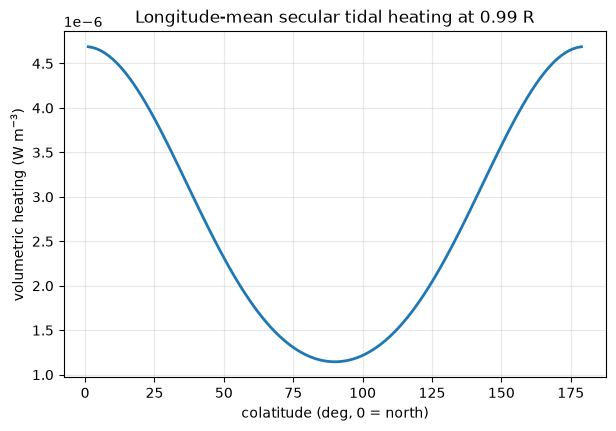

In [2]:
colats = np.linspace(0.02, np.pi - 0.02, 120)
# One call for all colatitudes at this radius. The radial problem is solved once.
h_surface = io.get_3d_tidal_heating_array(radii=0.99 * R, colatitudes=colats)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.degrees(colats), h_surface, lw=2)
ax.set_xlabel("colatitude (deg, 0 = north)")
ax.set_ylabel("volumetric heating (W m$^{-3}$)")
ax.set_title("Longitude-mean secular tidal heating at 0.99 R")
ax.grid(alpha=0.3)
plt.show()

## Surface Map

`calc_3d_tides` evaluates the field on a grid of radii, colatitudes, and longitudes and returns the `heating` array, which keeps the longitude dependence that the getters above average out. At 0.99 of the radius, the heating is symmetric about the equator and strongest toward the poles. At synchronous rotation it also depends on longitude. On the equator it is about ten times weaker at the sub-host and anti-host meridians (0 and 180 degrees) than at 90 and 270 degrees. Near the poles it barely changes with longitude.

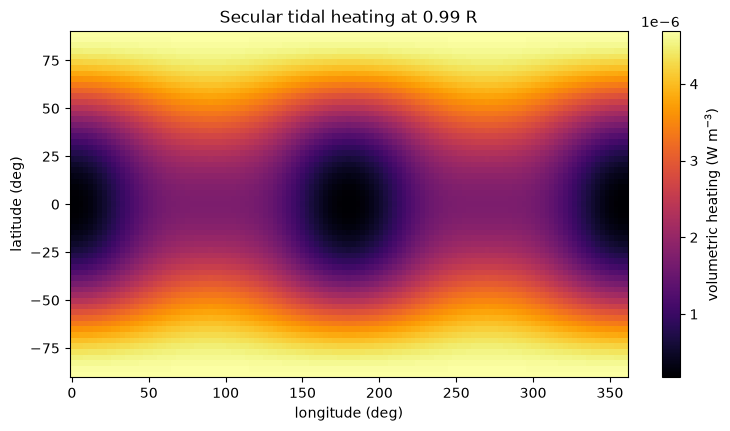

on the equator, heating at 90 deg / heating at 0 deg = 9.95


In [3]:
grid_colats = np.linspace(0.02, np.pi - 0.02, 61)   # The middle entry is the equator
grid_lons = np.linspace(0.0, 2.0 * np.pi, 121)      # 3 degree spacing
result = io.calc_3d_tides(radii=np.array([0.99 * R]), colatitudes=grid_colats, longitudes=grid_lons)
heat_map = np.asarray(result["heating"])[0]      # (colatitude, longitude)

fig, ax = plt.subplots(figsize=(9, 4.5))
mesh = ax.pcolormesh(np.degrees(grid_lons), 90.0 - np.degrees(grid_colats), heat_map, cmap="inferno", shading="auto")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_title("Secular tidal heating at 0.99 R")
fig.colorbar(mesh, ax=ax, label="volumetric heating (W m$^{-3}$)")
plt.show()
print(f"on the equator, heating at 90 deg / heating at 0 deg = {heat_map[30, 30] / heat_map[30, 0]:.2f}")

## Heating with Depth

In this homogeneous body, the polar heating density is largest near the center and about 7.5 times smaller just below the surface (left panel). Outer shells hold more volume, so the power per unit radius (right panel) peaks near 0.63 of the radius, and the outer quarter of the radius supplies about a quarter of the total. `calc_3d_tides` with `latitude_summed` and `longitude_summed` gives that power per unit radius \[W m$^{-1}$\] directly.

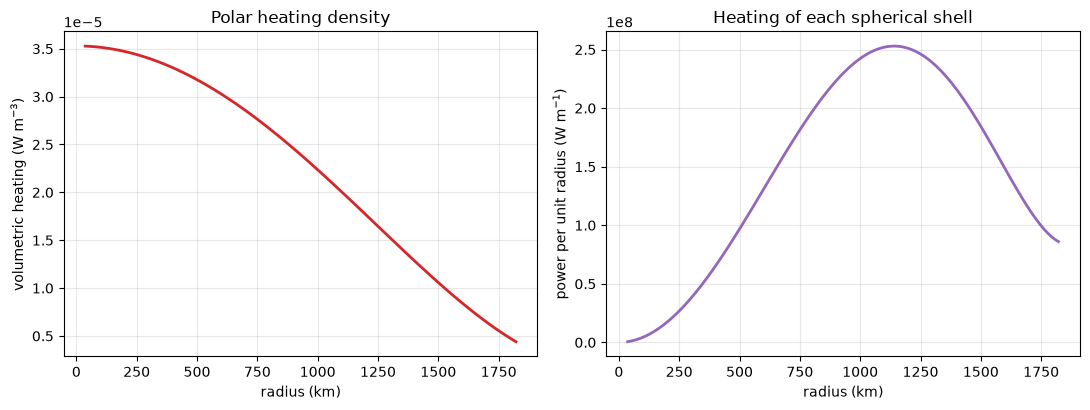

polar heating at 0.02 R / at 0.99 R = 7.54
power per unit radius peaks at 0.63 R
outer quarter of the radius: 25.7% of the total


In [4]:
radii = np.linspace(0.02 * R, R, 120)
# One call for the whole profile, near the north pole
h_polar = io.get_3d_tidal_heating_array(radii=radii, colatitudes=0.05)
# Integrated over each spherical shell: power per unit radius [W m-1]
h_shell = np.asarray(io.calc_3d_tides(radii=radii, latitude_summed=True, longitude_summed=True)["heating"])

fig, (ax_polar, ax_shell) = plt.subplots(1, 2, figsize=(11, 4.2))
ax_polar.plot(radii / 1.0e3, h_polar, lw=2, color="tab:red")
ax_polar.set_ylabel("volumetric heating (W m$^{-3}$)")
ax_polar.set_title("Polar heating density")
ax_shell.plot(radii / 1.0e3, h_shell, lw=2, color="tab:purple")
ax_shell.set_ylabel("power per unit radius (W m$^{-1}$)")
ax_shell.set_title("Heating of each spherical shell")
for ax in (ax_polar, ax_shell):
    ax.set_xlabel("radius (km)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

near_center, near_surface = io.get_3d_tidal_heating_array(radii=np.array([0.02 * R, 0.99 * R]), colatitudes=0.05)
outer = radii >= 0.75 * R
outer_fraction = trapezoid(h_shell[outer], radii[outer]) / trapezoid(h_shell, radii)
print(f"polar heating at 0.02 R / at 0.99 R = {near_center / near_surface:.2f}")
print(f"power per unit radius peaks at {radii[np.argmax(h_shell)] / R:.2f} R")
print(f"outer quarter of the radius: {outer_fraction:.1%} of the total")

## Consistency with the Total

Integrating the 3D field over the volume reproduces the total heating from `calc_tides`, to within the integration grid resolution. `calc_3d_tides` performs this integral when `latitude_summed`, `longitude_summed`, and `radial_summed` are `True`. With the default of 16 radial nodes per layer, the two agree to better than 0.1 parts per million here. The total, 2.65e14 W, is about 2.8 times the 9.3e13 W inferred for Io from its orbit (Lainey et al. 2009): this uniform Maxwell body is not fitted to Io.

The two agree whenever the eccentricity or the obliquity is zero. With both nonzero, the 3D field keeps cross terms between waves of the same degree, order, and frequency that the 1D sum, averaged over the argument of periapsis, drops. Near synchronous rotation the totals then differ slightly, as the second calculation below shows at $e = 0.1$ and an obliquity of 0.05 rad (with the eccentricity and obliquity truncations raised for those values only).

In [5]:
total_1d = io.calc_tides()["tidal_heating"]
summed = io.calc_3d_tides(latitude_summed=True, longitude_summed=True, radial_summed=True)
total_3d = float(np.asarray(summed["total"]))

print(f"Total from calc_tides       : {total_1d:.4e} W")
print(f"Volume Integral of 3D Field : {total_3d:.4e} W")
print(f"Relative difference         : {abs(total_3d / total_1d - 1.0):.1e}")

# Eccentricity and obliquity together: the settings apply inside the block only
with io.temporary_tide_config(eccentricity_truncation=10, obliquity_truncation=2):
    total_1d = io.calc_tides(eccentricity=0.1, obliquity=0.05)["tidal_heating"]
    summed = io.calc_3d_tides(eccentricity=0.1, obliquity=0.05, latitude_summed=True, longitude_summed=True,
                              radial_summed=True)
total_3d = float(np.asarray(summed["total"]))
print(f"\ne = 0.1, obliquity 0.05 rad: 3D total / 1D total - 1 = {total_3d / total_1d - 1.0:.1e}")

Total from calc_tides       : 2.6489e+14 W
Volume Integral of 3D Field : 2.6489e+14 W
Relative difference         : 2.1e-10

e = 0.1, obliquity 0.05 rad: 3D total / 1D total - 1 = -6.3e-04
